# AI-Generated vs. Real Image Classification

## Project Overview
This project aims to build a robust deep learning model capable of distinguishing between real photographs and AI-generated images. As Generative AI becomes more advanced, detecting synthetic media is crucial for security and authenticity verification.

## 1. Environment Setup & Data Preparation
In this section, we import the necessary libraries and set up the `ImageDataGenerator`. We apply data augmentation (shear, zoom, rotation, and horizontal flip) exclusively to the training set to improve model generalization and prevent overfitting. The images are resized to `(300, 300)`, which is the optimal input size for **EfficientNetB3**.

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-04 05:27:29.508397: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775280449.907965      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775280450.027084      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775280451.020204      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775280451.020244      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775280451.020247      55 computation_placer.cc:177] computation placer alr

In [3]:
import os
BASE_DIR = '/kaggle/input/notebooks/ziadalaaa/notebook5435188588/AI_Detection_Dataset'

train_dir = '/kaggle/input/notebooks/ziadalaaa/notebook5435188588/AI_Detection_Dataset/train'
val_dir = '/kaggle/input/notebooks/ziadalaaa/notebook5435188588/AI_Detection_Dataset/val'
test_dir = '/kaggle/input/notebooks/ziadalaaa/notebook5435188588/AI_Detection_Dataset/test'

In [4]:
IMG_SIZE=(300,300)
BATCH_SIZE=32

In [5]:
train_datagen1=ImageDataGenerator(
    shear_range=0.1,
    zoom_range=0.2,
    rotation_range=15,
    horizontal_flip=True
)

In [6]:
test_val_datagen1=ImageDataGenerator()

In [7]:
train_gen1=train_datagen1.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 35454 images belonging to 2 classes.


In [8]:
val_gen1=test_val_datagen1.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 4432 images belonging to 2 classes.


In [9]:
test_gen1=test_val_datagen1.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 4433 images belonging to 2 classes.


## 2. Exploratory Data Analysis (EDA): Dataset Distribution
Before training, it is essential to understand the distribution of our dataset across the `train`, `val`, and `test` splits. This step helps us identify if there is a class imbalance between the "Real" and "Fake" categories.

In [10]:
import os

BASE_DIR = '/kaggle/input/notebooks/ziadalaaa/notebook5435188588/AI_Detection_Dataset'
splits = ['train', 'val', 'test']
classes = ['real', 'fake']

print("Checking Dataset Balance...\n")

for split in splits:
    print(f"--- {split.upper()} SET ---")
    for cls in classes:
        dir_path = os.path.join(BASE_DIR, split, cls)
        if os.path.exists(dir_path):
            img_count = len(os.listdir(dir_path))
            print(f"{cls.capitalize()} images: {img_count}")
        else:
            print(f"Directory not found: {dir_path}")
    print("-" * 20)

Checking Dataset Balance...

--- TRAIN SET ---
Real images: 23455
Fake images: 11999
--------------------
--- VAL SET ---
Real images: 2932
Fake images: 1500
--------------------
--- TEST SET ---
Real images: 2932
Fake images: 1501
--------------------


## 3. Handling Class Imbalance
Based on the dataset distribution, there is a significant class imbalance (e.g., 23,455 Real images vs. 11,999 Fake images). To prevent the model from becoming biased towards the majority class, we compute **Class Weights**. These weights will heavily penalize the model for misclassifying the minority class during training.

In [11]:
total_real = 23455
total_fake = 11999
total = total_real + total_fake

weight_for_fake = total / (2.0 * total_fake)  
weight_for_real = total / (2.0 * total_real)  

class_weights = {
    0: weight_for_fake,  
    1: weight_for_real   
}

print(class_weights)

{0: 1.4773731144262021, 1: 0.7557876785333617}


## 4. Model Architecture: Transfer Learning with EfficientNetB3
We leverage **EfficientNetB3**, a state-of-the-art model pre-trained on ImageNet, due to its excellent balance between accuracy and computational efficiency. 
* **Base Model:** Loaded with ImageNet weights, excluding the top layers (`include_top=False`).
* **Custom Head:** We add a `GlobalAveragePooling2D` layer, followed by a `Dropout(0.5)` layer for regularization, and a final `Dense` layer with a sigmoid activation function for binary classification.

In [12]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [13]:
base_model=EfficientNetB3(weights="imagenet",include_top=False,input_shape=(300,300,3))

I0000 00:00:1775280569.049809      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775280569.055689      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
base_model.trainable=False

In [15]:
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dropout(0.5)(x)
output=Dense(1,activation="sigmoid")(x)

In [16]:
model=Model(inputs=base_model.input,outputs=output)

## 5. Phase 1 Training: Feature Extraction
In the first phase of training, we freeze the entire base model (`base_model.trainable = False`) to retain the pre-trained ImageNet features. We only train our custom classification head. 
* **Optimizer:** Adam with a learning rate of `1e-4`.
* **Callbacks:** `EarlyStopping` is utilized to monitor validation loss and prevent overfitting, restoring the best weights if the model stops improving.

In [17]:
model.compile(optimizer=Adam(1e-4),loss="binary_crossentropy",metrics=['accuracy'])

In [18]:
early_stop=EarlyStopping(
    patience=10,
    monitor="val_loss",
    restore_best_weights=True
)

In [19]:
model.fit(
    train_gen1,
    epochs=10,
    validation_data=val_gen1,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1775280592.643252     150 service.cc:152] XLA service 0x7c82dc01e2b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775280592.643303     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775280592.643310     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775280596.638116     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-04 05:30:09.454645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:30:09.611680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:30:10.056190: E external/local_xl

 952/1108 ━━━━━━━━━━━━━━━━━━━━ 2:59 1s/step - accuracy: 0.6572 - loss: 0.6282

2026-04-04 05:48:54.870759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:48:55.026757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:48:55.481694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:48:55.628607: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:48:56.461436: E external/local_xla/xla/stream_

1108/1108 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6675 - loss: 0.6195

2026-04-04 05:53:56.966892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:53:57.111362: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:53:57.470628: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:53:57.618183: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 05:53:58.407743: E external/local_xla/xla/stream_

1108/1108 ━━━━━━━━━━━━━━━━━━━━ 1469s 1s/step - accuracy: 0.6676 - loss: 0.6195 - val_accuracy: 0.8071 - val_loss: 0.4539
Epoch 2/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 979s 883ms/step - accuracy: 0.7969 - loss: 0.4740 - val_accuracy: 0.8459 - val_loss: 0.3906
Epoch 3/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 998s 901ms/step - accuracy: 0.8301 - loss: 0.4234 - val_accuracy: 0.8610 - val_loss: 0.3570
Epoch 4/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 985s 889ms/step - accuracy: 0.8427 - loss: 0.4005 - val_accuracy: 0.8696 - val_loss: 0.3354
Epoch 5/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 971s 876ms/step - accuracy: 0.8515 - loss: 0.3722 - val_accuracy: 0.8736 - val_loss: 0.3217
Epoch 6/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 982s 887ms/step - accuracy: 0.8598 - loss: 0.3594 - val_accuracy: 0.8759 - val_loss: 0.3111
Epoch 7/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 1008s 909ms/step - accuracy: 0.8617 - loss: 0.3526 - val_accuracy: 0.8795 - val_loss: 0.3015
Epoch 8/10
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 977s 882ms/step - accuracy: 0.86

## 6. Phase 2 Training: Fine-Tuning
To maximize the model's performance on our specific dataset, we perform fine-tuning. We unfreeze the base model but keep all layers frozen except for the **last 30 layers**.
* **Optimizer Adjustment:** We recompile the model with a significantly lower learning rate (`1e-5`) to carefully adapt the pre-trained weights without causing catastrophic forgetting of the ImageNet features.

In [21]:
base_model.trainable = True

In [22]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [23]:
model.compile(optimizer=Adam(1e-5), loss="binary_crossentropy", metrics=['accuracy'])

In [24]:
history_phase2 = model.fit(
    train_gen1,
    epochs=100, 
    validation_data=val_gen1,
    callbacks=[early_stop], 
    class_weight=class_weights
   )

Epoch 1/100


2026-04-04 08:21:46.999369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:21:47.146582: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:21:47.989377: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:21:48.127994: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:21:48.418978: E external/local_xla/xla/stream_

 183/1108 ━━━━━━━━━━━━━━━━━━━━ 13:02 846ms/step - accuracy: 0.7563 - loss: 0.4392

2026-04-04 08:24:45.336751: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:24:45.483554: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:24:46.311559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:24:46.450297: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 08:24:46.736806: E external/local_xla/xla/stream_

1108/1108 ━━━━━━━━━━━━━━━━━━━━ 1087s 943ms/step - accuracy: 0.8203 - loss: 0.3649 - val_accuracy: 0.8727 - val_loss: 0.2836
Epoch 2/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 1006s 907ms/step - accuracy: 0.8975 - loss: 0.2457 - val_accuracy: 0.8870 - val_loss: 0.2473
Epoch 3/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 989s 892ms/step - accuracy: 0.9154 - loss: 0.2074 - val_accuracy: 0.8910 - val_loss: 0.2404
Epoch 4/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 988s 892ms/step - accuracy: 0.9255 - loss: 0.1853 - val_accuracy: 0.8989 - val_loss: 0.2270
Epoch 5/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 1051s 949ms/step - accuracy: 0.9348 - loss: 0.1713 - val_accuracy: 0.9016 - val_loss: 0.2248
Epoch 6/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 978s 882ms/step - accuracy: 0.9356 - loss: 0.1656 - val_accuracy: 0.8940 - val_loss: 0.2356
Epoch 7/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 984s 888ms/step - accuracy: 0.9429 - loss: 0.1447 - val_accuracy: 0.9030 - val_loss: 0.2274
Epoch 8/100
1108/1108 ━━━━━━━━━━━━━━━━━━━━ 989s 892ms/step - acc

## 7. Model Evaluation on Unseen Data
After completing the fine-tuning process, we evaluate the model's final performance on the independent `test` dataset to ensure it generalizes well to entirely new, unseen images.

In [26]:
test_loss,test_accuracy=model.evaluate(test_gen1)

138/139 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.9410 - loss: 0.1407

2026-04-04 13:45:37.047054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 13:45:37.192278: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 13:45:37.554139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 13:45:37.700991: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 13:45:38.487042: E external/local_xla/xla/stream_

139/139 ━━━━━━━━━━━━━━━━━━━━ 115s 831ms/step - accuracy: 0.9403 - loss: 0.1422


## 8. Performance Metrics & Visualization
To deeply understand where our model excels and where it struggles, we extract predictions and visualize the results using:
1. **Confusion Matrix:** To see the exact number of True Positives, True Negatives, False Positives, and False Negatives.
2. **ROC Curve (Receiver Operating Characteristic):** To measure the model's ability to distinguish between the two classes (AUC score).
3. **Classification Report:** To analyze precision, recall, and F1-score for each individual class.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [28]:
predictions = model.predict(test_gen1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = test_gen1.classes 

139/139 ━━━━━━━━━━━━━━━━━━━━ 70s 433ms/step


In [29]:
cm = confusion_matrix(y_true, y_pred)

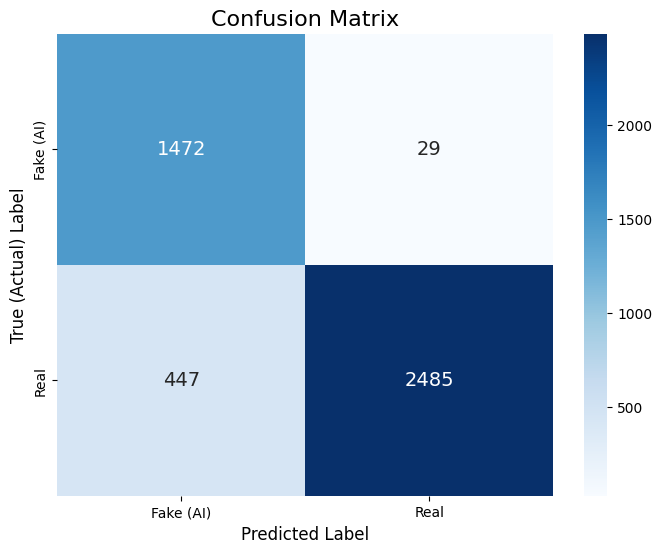

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake (AI)', 'Real'], 
            yticklabels=['Fake (AI)', 'Real'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True (Actual) Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

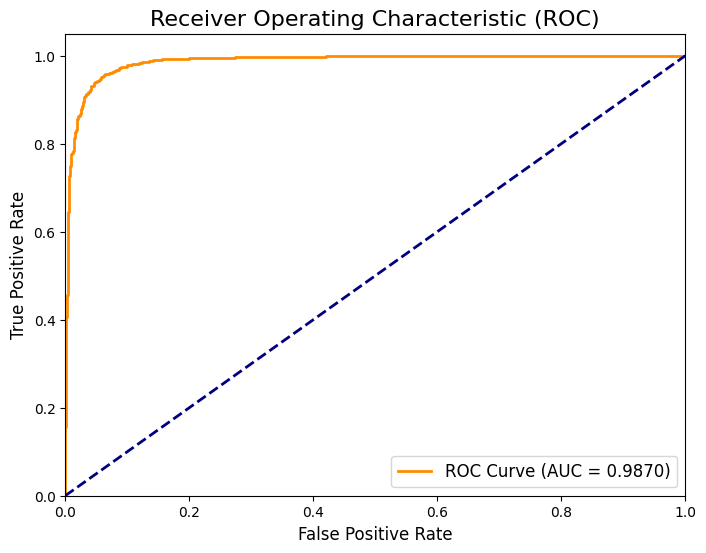

In [31]:
fpr, tpr, thresholds = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.show()

In [32]:
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Fake (AI)', 'Real']))


📑 Classification Report:
              precision    recall  f1-score   support

   Fake (AI)       0.77      0.98      0.86      1501
        Real       0.99      0.85      0.91      2932

    accuracy                           0.89      4433
   macro avg       0.88      0.91      0.89      4433
weighted avg       0.91      0.89      0.90      4433

